In [4]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [5]:
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df_cleaned = pd.read_csv('data/df_cleaned.csv')
display(df_cleaned.head())

c:\Users\kims\Documents\airbnb_price_prediction


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.0,60.0,3.0,60.0,True,30,49,66,326,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,False,1,0,1,0,0.28,1,1,1,6.641182,0.000000
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,1.0,0.97,True,Harlem,1.0,1.0,True,True,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139.0,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,True,7,18,25,25,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,False,1,1,0,0,1.36,1,1,0,4.941642,10.475

# 주요 변수와 가격(price)과의 상관관계 분석-> 7개+리뷰, 평점
    주요 변수: 
        리뷰관련 + 평점, 
        estimated_occupancy_l365d (지난 365일(1년) 동안 숙소가 얼마나 이 숙소가 얼마나 찼었는지 추정한 점유율)
        property_type (숙소 타입) 
        room_type (룸 타입)
        host_is_superhost (슈퍼 호스트 여부)
        host_response_rate  (호스트 응답률)
        host_acceptance_rate (호스트 수락률)
제외한 컬럼: 리뷰 관련+평점 어떻게 해야할지 감이 안오므로, 제외하고 진행. 

In [20]:
#호스트 관련 주요 변수(host_is_superhost, host_response_rate, host_acceptance_rate)와 가격(price)과의 상관관계 분석
host_relevant_cols = ['price', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate']
df_host_relevant = df_cleaned[host_relevant_cols]

# host_is_superhost를 True: 1, False: 0으로 변환

In [21]:
# host_is_superhost 컬럼의 고유값 확인
print(df_host_relevant['host_is_superhost'].unique())

[False True nan]


In [22]:
# host_is_superhost 컬럼을 'True'를 1로, 'False'를 0으로 변환
df_host_relevant['host_is_superhost'] = df_host_relevant['host_is_superhost'].map({True: 1, False: 0})
print(df_host_relevant['host_is_superhost'].unique())

[ 0.  1. nan]


In [23]:
# 선택한 컬럼들의 타입만 출력
print(df_host_relevant.dtypes)

price                   float64
host_is_superhost       float64
host_response_rate      float64
host_acceptance_rate    float64
dtype: object


# 시각화

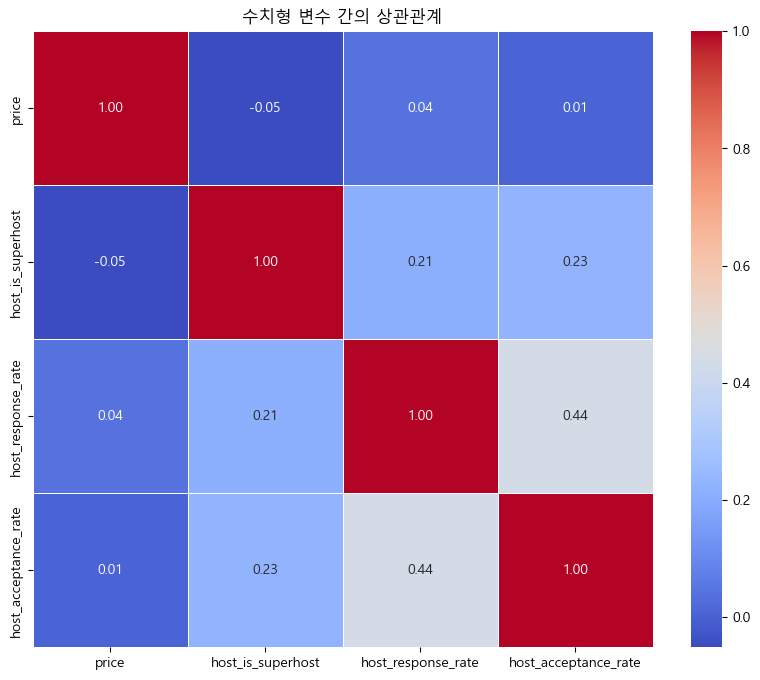

In [24]:
# 히트맵으로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(df_host_relevant.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('수치형 변수 간의 상관관계')
plt.show()

In [26]:
# 호스트와 관련된 주요 변수와 가격과의 상관관계 분석 결과
print("호스트 관련 주요 변수와 가격과의 상관관계 분석 결과:")
print(df_host_relevant.corr()['price'].sort_values(ascending=False))

호스트 관련 주요 변수와 가격과의 상관관계 분석 결과:
price                   1.000000
host_response_rate      0.042325
host_acceptance_rate    0.006481
host_is_superhost      -0.051083
Name: price, dtype: float64


## price 변수들은 상관관계가 거의 없음. 
-> 슈퍼호스트라고 가격이 더 비싼 것도 아니였으며, 응답률과 수락률과는 상관관계가 미미한 수준이었다.